# Importing data for time and frequency series anlaysis

In [26]:
#checking speed
start=time.time()
raw = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south", sep=r"\s+", header=None)  # fast read
end=time.time()
print(raw.head())
print("time for pd.read_csv():", end - start)

       0       1       2       3       4       5
0  34.25  0.3832  20.744  39.056  0.3500  0.1979
1  34.25  1.1495  20.748  39.055  0.3368  0.1997
2  34.25  1.9158  20.753  39.053  0.3203  0.2021
3  34.25  3.0652  20.760  39.049  0.2958  0.2060
4  34.25  4.5978  20.764  39.047  0.2824  0.2083
time for pd.read_csv(): 90.86028456687927


In [13]:
#checking number of rows read
raw = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south").values  # [nx*nz*nt, 6]
print(raw.shape[0])

23594687


In [22]:
#comparing header detection
import pandas as pd

a = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south",  header=None).shape[0]
b = pd.read_csv("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south", ).shape[0]   # default: first row as header
print("with header=None:", a)
print("without (default):", b)

with header=None: 23594688
without (default): 23594687


## Creating function to load dataset into time series arrays that are easy to access and remember for future analysis (translated from matlab)

In [26]:
import numpy as np
import pandas as pd

def load_ocean_data(filename, nz, nx, nt, latitude, start_time, time_resolution=1):
    """Direct translation of the MATLAB load_ocean_data.

    File columns: [lon, depth, temp, salinity, u, v].
    Returns a dict with 3D fields indexed [depth, lon, time].
    """
    raw = pd.read_csv(filename, sep=r"\s+", header=None).values #reads file where row values are seperated by space delimitter and no col header is present
    if raw.shape[0] != nx * nz * nt:
        raise ValueError("Data length does not match nx*nz*nt. Check input values. ") #return error if sample size is not as expected

    #initialize vectors for variables
    temperature = np.zeros((nz, nx, nt)) #[depth, lon, time]
    salinity    = np.zeros((nz, nx, nt)) #[depth, lon, time]
    u           = np.zeros((nz, nx, nt)) #[depth, lon, time]
    v           = np.zeros((nz, nx, nt)) #[depth, lon, time]
    depth       = np.zeros((nz, nx)) #[depth, lon]
    lon         = np.zeros((nz, nx)) #[depth, lon]

    for t in range(nt):
        frame = raw[t*nx*nz:(t+1)*nx*nz, :]            # [nz*nx, 6] 
        # MATLAB reshape is column-major -> order="F"
        temperature[:, :, t] = frame[:, 2].reshape(nz, nx, order="F") 
        salinity[:, :, t]    = frame[:, 3].reshape(nz, nx, order="F")
        u[:, :, t]           = frame[:, 4].reshape(nz, nx, order="F")
        v[:, :, t]           = frame[:, 5].reshape(nz, nx, order="F")
        if t == 0:
            depth = frame[:, 1].reshape(nz, nx, order="F")
            lon   = frame[:, 0].reshape(nz, nx, order="F")

    # Generate time vector
    time_vec = pd.date_range(start=start_time, periods=nt, freq=f"{time_resolution}h")

    return {
        "temp": temperature, "sal": salinity, "u": u, "v": v,
        "depth": depth, "lon": lon, "time": time_vec,
        "lat": latitude, "nx": nx, "nz": nz, "nt": nt,
        "timeRes": time_resolution,
    }

## Test same data loading function in SRC

temp shape [depth, lon, time]: (39, 23, 26304)
surface temp, westernmost, first hour: 20.744 (expect ~29.038) depth: 0.38
deepest temp, westernmost, first hour: 14.162 (expect ~14.125) depth: 630.67
first time: 2016-01-01 13:00:00 | last time: 2019-01-01 12:00:00


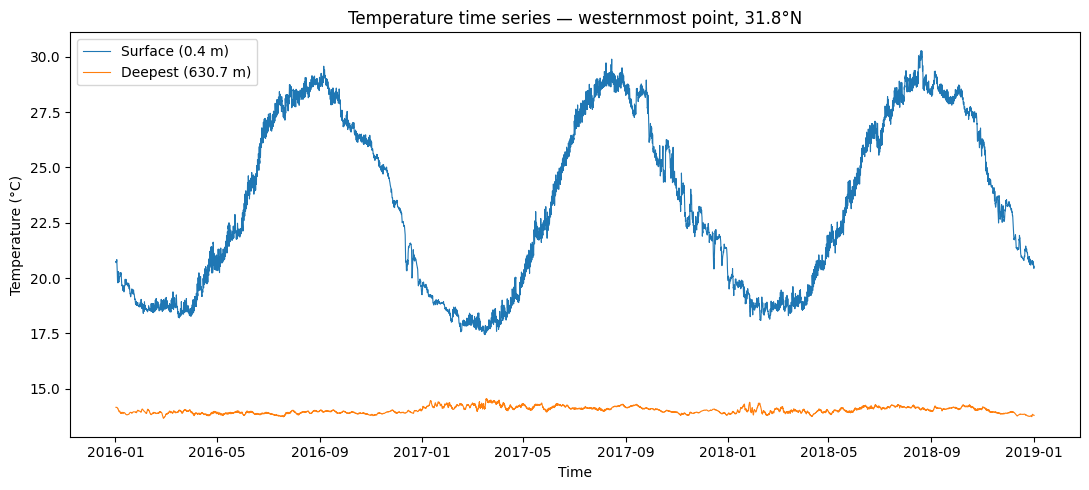

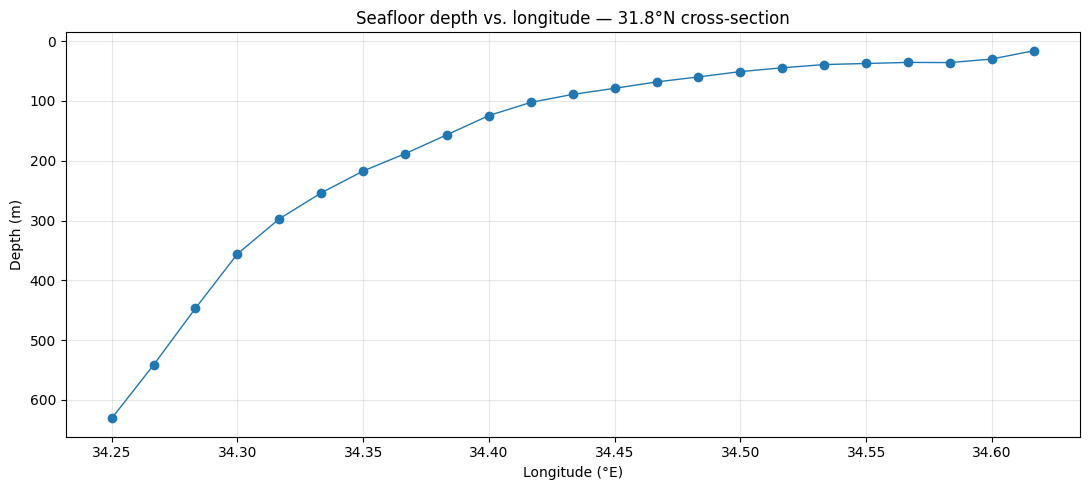

In [1]:
import sys
sys.path.append("..")  # notebooks/ is one level below root
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.load_ocean_data import load_ocean_data

d = load_ocean_data("C:/Users/IMG/Documents/ocean-timeseries-ml/data/raw/xsec_south",
                    nz=39, nx=23, nt=26304, latitude=31.8,
                    start_time=pd.Timestamp("2016-01-01 13:00"),
                    time_resolution=1)

# --- Quick sanity checks ---
print("temp shape [depth, lon, time]:", d["temp"].shape)
print("surface temp, westernmost, first hour:", round(d["temp"][0, 0, 0], 3), "(expect ~29.038)", "depth:", round(d["depth"][0, 0], 2))
print("deepest temp, westernmost, first hour:", round(d["temp"][-1, 0, 0], 3), "(expect ~14.125)", "depth:", round(d["depth"][-1, 0], 2))
print("first time:", d["time"][0], "| last time:", d["time"][-1])

# --- Pull two time series at the westernmost longitude (j=0) ---
surface = d["temp"][0, 0, :]     # depth index 0  = surface
deepest = d["temp"][-1, 0, :]    # depth index -1 = deepest level
time = d["time"]

# --- Plot 1: temperature time series ---
plt.figure(figsize=(11, 5))
plt.plot(time, surface, label=f"Surface ({d['depth'][0, 0]:.1f} m)", linewidth=0.8)
plt.plot(time, deepest, label=f"Deepest ({d['depth'][-1, 0]:.1f} m)", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Temperature time series — westernmost point, {d['lat']}°N")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: seafloor depth as a function of longitude (bathymetry) ---
lon = d["lon"]                 # 1D longitude values
seafloor = d["depth"][-1, :]   # deepest level at each longitude = seafloor

plt.figure(figsize=(11, 5))
plt.plot(lon, seafloor, marker="o", linewidth=1)
plt.gca().invert_yaxis()       # depth increases downward
plt.xlabel("Longitude (°E)")
plt.ylabel("Depth (m)")
plt.title(f"Seafloor depth vs. longitude — {d['lat']}°N cross-section")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()